# 01 — Data Understanding (EDA + Decision Log)

**Layer 1 notebook.** Answers: what is the prediction problem, what does the data show,
how must it be cleaned and split, and which feature hypotheses are worth testing?

**Does not:** fit GBDT, run HPO, learn global imputation/scaling for modeling, or create submissions.

**Skills read (project-local `.agent/skills/`):**
- `tabular-time-series-lifecycle` — T0/L/H, seasonal-naive before complex models, walk-forward, fold-local transforms
- `tabular-time-series-eda` — temporal schema, panel EDA, O/I/A, leakage-aware covariates
- `tabular-eda-mentorship` — problem contract, thin notebook + modular helpers, decision log
- `tabular-ml-visual-diagnostics` — phase-matched charts with decisions, not decoration
- `tabular-time-series-imbalance-handling` — zero-inflation / intermittent demand as signal (not SMOTE)
- `tabular-time-series-outlier-handling` — classify before treat; no row deletion; train-only caps if any
- `tabular-outlier-handling` — preserve extremes as evidence; fold-local policy
- `tabular-time-series-data-leakage-control` — FAM / availability / chronological split first
- `better-jupyter-notebook` — Markdown before code; O/I/A; no fabricated numbers
- `jupytext-notebook-workflows` — optional `ipynb,py:percent` pairing
- `python-observability` — structured logging for load/audit steps
- Supporting: `data-storytelling`, `ml-reproducibility-seed-control`

**Not applied as primary path:** threshold-tuning, probability-calibration (RMSLE point forecast).

## 0. Problem Contract

| Field | Decision |
| --- | --- |
| Task | Multi-series panel **point forecast** of unit sales |
| Unit of observation | `(date, store_nbr, family)` — one row per store×product-family×day |
| Target | `sales` (non-negative continuous; fractional units allowed) |
| Forecast origin `T0` | End of training history for a given submission / fold (last train date) |
| Lead time `L` | `0` days — first forecast day is `T0 + 1` |
| Horizon `H` | **15 days** (competition test length) |
| Entities | 54 stores × 33 families |
| Frequency | Daily |
| Metric | **RMSLE** = `sqrt(mean((log1p(pred) - log1p(true))**2))` via `store_sales.metrics.rmsle` |
| Cost asymmetry | Over-forecast → waste/spoilage; under-forecast → stockout / lost sales. RMSLE penalizes relative error and is defined for zeros via `log1p`. |
| Known-ahead covariates | Calendar; `onpromotion` provided on test for the horizon; holiday flags (with transfer semantics) |
| Observed-past covariates | Oil price (with lag/availability care), transactions (store-day; **not** available for full test window as future) |
| Split | Expanding walk-forward, 15-day val blocks, manifests under `data/splits/` |
| Forbidden | Random K-fold; global pre-split scalers; unshifted rolling target; deleting rare-valid spikes |
| Main risks | Zero-inflation; earthquake 2016-04-16 regime; oil missingness; holiday transfer semantics; intermittent families |

## 1. Setup — seeds, paths, logging

Purpose: lock PRNG seed, configure logging, ensure EDA figure directory exists.

In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:  # plain script fallback
    def display(obj):  # type: ignore[misc]
        print(obj)

# Project root = parent of notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from store_sales.config import ProjectPaths, load_default_config
from store_sales.data.outliers import describe_sales_tails, flag_invalid_sales
from store_sales.io.logging import get_logger
from store_sales.metrics import rmsle
from store_sales.viz.eda_plots import (
    plot_aggregate_sales_over_time,
    plot_dow_seasonality,
    plot_fold_date_ranges,
    plot_oil_missingness,
    plot_store_family_panels,
    plot_target_distribution,
    plot_zero_mass_by_family,
    save_figure,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

cfg = load_default_config()
paths = ProjectPaths()  # package root via store_sales.config
INTERIM = paths.data_interim
SPLITS = paths.data_splits
EDA_DIR = paths.outputs / "reports" / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

logger = get_logger("notebook.01_data_understanding")
logger.info("ROOT=%s SEED=%s EDA_DIR=%s", ROOT, SEED, EDA_DIR)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

print(f"seed={SEED}")
print(f"interim={INTERIM}")
print(f"splits={SPLITS}")
print(f"eda_dir={EDA_DIR}")
print(f"horizon_days={cfg.get('horizon_days')} metric={cfg.get('metric')}")

INFO 2026-07-17 02:56:03 ROOT=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting SEED=42 EDA_DIR=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/outputs/reports/eda


seed=42
interim=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/interim
splits=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/splits
eda_dir=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/outputs/reports/eda
horizon_days=15 metric=rmsle


## 2. Load interim tables + schema map

Purpose: load cleaned interim parquets produced by `scripts/prepare_data.py` and
classify columns by semantic type (not just dtype).

In [2]:
TABLE_NAMES = [
    "train",
    "test",
    "stores",
    "oil",
    "holidays_events",
    "transactions",
    "sample_submission",
]
tables: dict[str, pd.DataFrame] = {}
for name in TABLE_NAMES:
    p = INTERIM / f"{name}.parquet"
    df = pd.read_parquet(p)
    tables[name] = df
    logger.info("loaded %s shape=%s path=%s", name, df.shape, p)

train = tables["train"]
# Memory-friendly dtypes for ~3M-row panel (honest full-data analysis, lighter RAM)
train["store_nbr"] = train["store_nbr"].astype("int16")
train["onpromotion"] = train["onpromotion"].astype("int32")
train["family"] = train["family"].astype("category")
train["sales"] = train["sales"].astype("float32")
tables["train"] = train

test = tables["test"]
test["store_nbr"] = test["store_nbr"].astype("int16")
test["family"] = test["family"].astype("category")
tables["test"] = test

stores = tables["stores"]
oil = tables["oil"]
holidays = tables["holidays_events"]
transactions = tables["transactions"]
logger.info("train mem_mb=%.1f", train.memory_usage(deep=True).sum() / 1e6)

schema_rows = []
semantic_map = {
    "train": {
        "id": "row_id",
        "date": "timestamp",
        "store_nbr": "entity_id",
        "family": "entity_id",
        "sales": "target",
        "onpromotion": "known_future_covariate",
    },
    "test": {
        "id": "row_id",
        "date": "timestamp",
        "store_nbr": "entity_id",
        "family": "entity_id",
        "onpromotion": "known_future_covariate",
    },
    "stores": {
        "store_nbr": "entity_id",
        "city": "static_covariate",
        "state": "static_covariate",
        "type": "static_covariate",
        "cluster": "static_covariate",
    },
    "oil": {
        "date": "timestamp",
        "dcoilwtico": "observed_past_covariate",
    },
    "holidays_events": {
        "date": "timestamp",
        "type": "known_future_covariate",
        "locale": "known_future_covariate",
        "locale_name": "known_future_covariate",
        "description": "known_future_covariate",
        "transferred": "known_future_covariate",
    },
    "transactions": {
        "date": "timestamp",
        "store_nbr": "entity_id",
        "transactions": "observed_past_covariate",
    },
}
for tname, smap in semantic_map.items():
    df = tables[tname]
    for col, sem in smap.items():
        schema_rows.append(
            {
                "table": tname,
                "column": col,
                "dtype": str(df[col].dtype) if col in df.columns else "MISSING",
                "semantic_type": sem,
                "n_unique": int(df[col].nunique()) if col in df.columns else None,
                "n_missing": int(df[col].isna().sum()) if col in df.columns else None,
            }
        )
schema_df = pd.DataFrame(schema_rows)
display(schema_df)

print("train date range:", train["date"].min(), "→", train["date"].max())
print("test  date range:", test["date"].min(), "→", test["date"].max())
print(
    "n_stores",
    train["store_nbr"].nunique(),
    "n_families",
    train["family"].nunique(),
    "n_panel_keys",
    train.groupby(["store_nbr", "family"]).ngroups,
)

INFO 2026-07-17 02:56:03 loaded train shape=(3000888, 6) path=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/interim/train.parquet


INFO 2026-07-17 02:56:03 loaded test shape=(28512, 5) path=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/interim/test.parquet


INFO 2026-07-17 02:56:03 loaded stores shape=(54, 5) path=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/interim/stores.parquet


INFO 2026-07-17 02:56:03 loaded oil shape=(1218, 2) path=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/interim/oil.parquet


INFO 2026-07-17 02:56:03 loaded holidays_events shape=(350, 6) path=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/interim/holidays_events.parquet


INFO 2026-07-17 02:56:03 loaded transactions shape=(83488, 3) path=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/interim/transactions.parquet


INFO 2026-07-17 02:56:03 loaded sample_submission shape=(28512, 2) path=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/data/interim/sample_submission.parquet


INFO 2026-07-17 02:56:03 train mem_mb=81.0


,table,column,dtype,semantic_type,n_unique,n_missing
0,train,id,int64,row_id,3000888,0
1,train,date,datetime64[us],timestamp,1684,0
2,train,store_nbr,int16,entity_id,54,0
3,train,family,category,entity_id,33,0
4,train,sales,float32,target,379610,0
5,train,onpromotion,int32,known_future_covariate,362,0
6,test,id,int64,row_id,28512,0
7,test,date,datetime64[us],timestamp,16,0
8,test,store_nbr,int16,entity_id,54,0
9,test,family,category,entity_id,33,0


train date range: 2013-01-01 00:00:00 → 2017-08-15 00:00:00
test  date range: 2017-08-16 00:00:00 → 2017-08-31 00:00:00
n_stores 54 n_families 33 n_panel_keys 1782


### Schema — Observation / Interpretation / Action

**Observation:** Train covers 2013-01-01 → 2017-08-15; test continues for ~15 days after train end.
Panel grain is `(date, store_nbr, family)` with target `sales` and known-ahead-style `onpromotion`.
Oil and transactions are observed-past exogenous series; holidays are calendar (known ahead) with a `transferred` flag.

**Interpretation:** Modeling must be multi-series daily forecasting with `H=15`, `L=0`. Static store metadata joins on `store_nbr` only. Oil/transactions need availability rules (no using future oil or future transactions at `T0`).

**Action:** Keep interim schema; use walk-forward 15-day folds; build FAM for oil (lag if market close not known same day) and transactions (train-only history features, not test-horizon raw joins).

## 3. Data-quality audit

Purpose: zeros, missing oil (raw vs cleaned), holiday types, transactions coverage, duplicates, negatives.

In [3]:
# --- Train panel integrity ---
n_neg = int(flag_invalid_sales(train).sum())
n_dup = int(train.duplicated(["date", "store_nbr", "family"]).sum())
zero_rate = float((train["sales"] == 0).mean())
print(f"negative_sales={n_neg} duplicate_keys={n_dup} global_zero_rate={zero_rate:.4%}")
print("sales describe:\n", train["sales"].describe(percentiles=[0.5, 0.9, 0.99, 0.999]))

# --- Oil: raw vs interim (interim already ffilled by prepare_data) ---
raw_oil_path = paths.data_raw / "oil.csv"
if raw_oil_path.exists():
    oil_raw = pd.read_csv(raw_oil_path, parse_dates=["date"])
    print(
        f"oil RAW missing={oil_raw['dcoilwtico'].isna().sum()} / {len(oil_raw)} "
        f"({oil_raw['dcoilwtico'].isna().mean():.2%})"
    )
else:
    oil_raw = None
    print("raw oil.csv not found; skip raw missing count")
print(
    f"oil INTERIM missing={oil['dcoilwtico'].isna().sum()} / {len(oil)} "
    f"(leading NaN expected after causal ffill)"
)

# --- Holidays ---
print("\nholiday type counts:\n", holidays["type"].value_counts())
print("locale counts:\n", holidays["locale"].value_counts())
print("transferred true:", int(holidays["transferred"].astype(bool).sum()))

# --- Transactions coverage vs train stores/dates ---
tr_dates = transactions["date"]
print(
    "\ntransactions date range:",
    tr_dates.min(),
    "→",
    tr_dates.max(),
    "n_stores",
    transactions["store_nbr"].nunique(),
)
# Fraction of train store-days that have a transactions row
store_days = train[["date", "store_nbr"]].drop_duplicates()
merged_tx = store_days.merge(
    transactions[["date", "store_nbr", "transactions"]],
    on=["date", "store_nbr"],
    how="left",
)
tx_cov = float(merged_tx["transactions"].notna().mean())
print(f"train store-day transactions coverage={tx_cov:.2%}")

# Test has no sales; check onpromotion present
print("test missing onpromotion:", int(test["onpromotion"].isna().sum()))
print("sample_submission rows:", len(tables["sample_submission"]), "test rows:", len(test))

negative_sales=0 duplicate_keys=0 global_zero_rate=31.2951%
sales describe:
 count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
50%      1.100000e+01
90%      8.670000e+02
99%      5.507000e+03
99.9%    1.207623e+04
max      1.247170e+05
Name: sales, dtype: float64
oil RAW missing=43 / 1218 (3.53%)
oil INTERIM missing=1 / 1218 (leading NaN expected after causal ffill)

holiday type counts:
 type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64
locale counts:
 locale
National    174
Local       152
Regional     24
Name: count, dtype: int64
transferred true: 12

transactions date range: 2013-01-01 00:00:00 → 2017-08-15 00:00:00 n_stores 54
train store-day transactions coverage=91.81%
test missing onpromotion: 0
sample_submission rows: 28512 test rows: 28512


### DQ audit — Observation / Interpretation / Action

**Observation:** No negative sales and no duplicate panel keys after structural clean. Global zero rate is large (~31%). Raw oil had dozens of missing business-day prices; interim oil has only leading residual NaN after causal `ffill`. Holidays include Transfer / Bridge / Work Day / transferred flags. Transactions do not cover 100% of store-days and end with the train window (not a free future feature for the full test horizon).

**Interpretation:** Zeros are structural intermittency for many families, not ETL failure. Oil ffill is the correct causal policy; remaining leading NA must be handled fold-locally (constant or drop early history). Transactions are lag/history features only. Holiday feature engineering must honor `transferred` (non-celebrated calendar markers).

**Action:** Confirm oil ffill for Task 6+ pipelines; never bfill. Do not impute zeros as missing. Engineer holiday features from type/locale/transferred. Transactions → lag/rolling at store level with train-only availability.

## 4. Visual diagnostics pack

Purpose: target distribution / zero mass, aggregate series, sample panels, DOW seasonality, oil missingness.

Target hist/KDE sample size: 300,000 of 3,000,888 rows


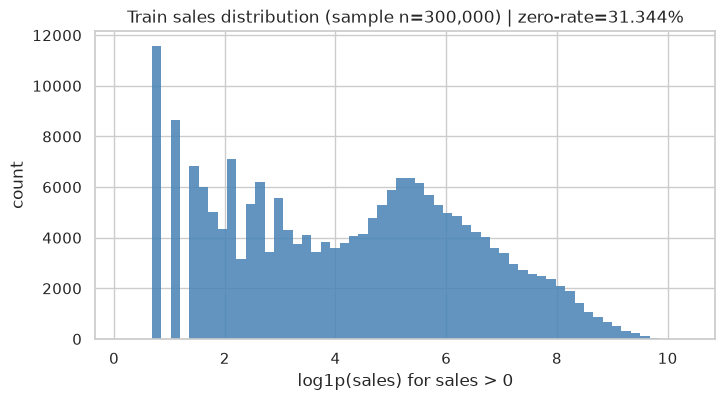

Full-data zero rate: 31.2951%


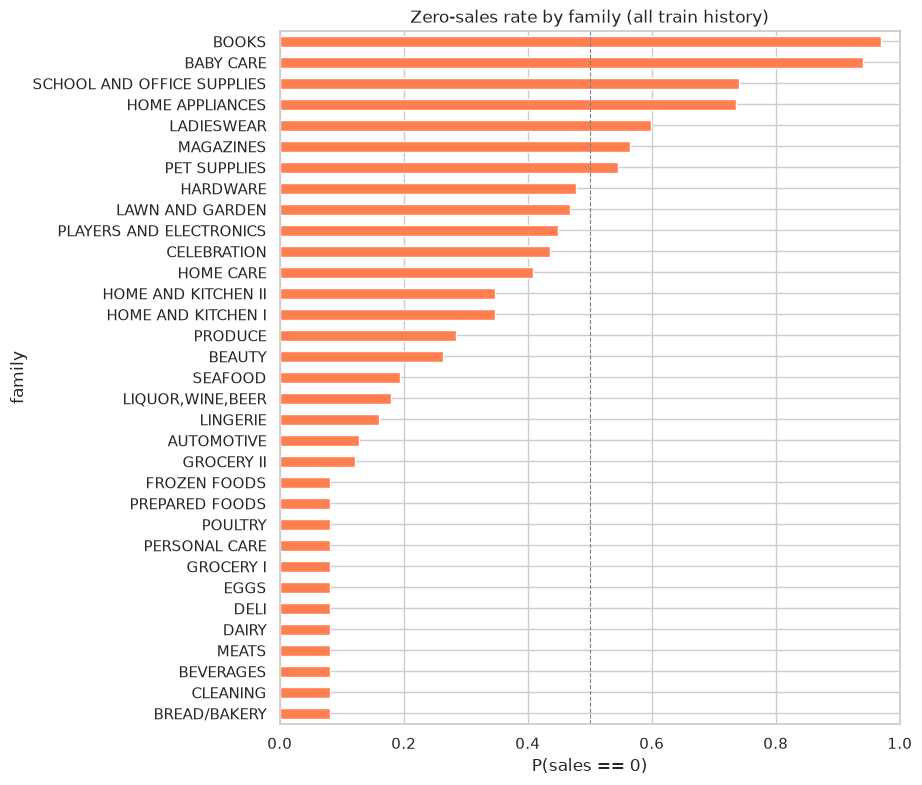

Top intermittent families:
 family
BOOKS                         0.969550
BABY CARE                     0.941310
SCHOOL AND OFFICE SUPPLIES    0.740829
HOME APPLIANCES               0.735176
LADIESWEAR                    0.598465
MAGAZINES                     0.565387
PET SUPPLIES                  0.546153
HARDWARE                      0.478622
LAWN AND GARDEN               0.467846
PLAYERS AND ELECTRONICS       0.448865

Lowest zero-rate families:
 family
DELI            0.080617
DAIRY           0.080617
CLEANING        0.080617
MEATS           0.080617
BREAD/BAKERY    0.080606


In [4]:
# Target distribution (log1p of positive sales) — sample for KDE speed/RAM; report sample size
_sales_sample_n = min(300_000, len(train))
sales_sample = train["sales"].sample(n=_sales_sample_n, random_state=SEED)
print(f"Target hist/KDE sample size: {_sales_sample_n:,} of {len(train):,} rows")
fig, ax = plt.subplots(figsize=(8, 4))
plot_target_distribution(
    sales_sample,
    ax=ax,
    title=f"Train sales distribution (sample n={_sales_sample_n:,})",
    save_path=EDA_DIR / "01_target_distribution_log1p.png",
)
plt.show()
plt.close(fig)
# Full-data zero rate (cheap)
print(f"Full-data zero rate: {(train['sales'] == 0).mean():.4%}")

# Zero mass by family (full data, vectorized)
family_zero = (
    train.assign(_z=train["sales"].eq(0))
    .groupby("family", observed=True)["_z"]
    .mean()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 9))
plot_zero_mass_by_family(
    family_zero,
    ax=ax,
    title="Zero-sales rate by family (all train history)",
    save_path=EDA_DIR / "02_zero_rate_by_family.png",
)
plt.show()
plt.close(fig)
print("Top intermittent families:\n", family_zero.head(10).to_string())
print("\nLowest zero-rate families:\n", family_zero.tail(5).to_string())

### Target / zero mass — O/I/A

**Observation:** Sales are heavily right-skewed; a large share of cells are exact zeros. Families such as BOOKS, BABY CARE, SCHOOL AND OFFICE SUPPLIES show extreme intermittency; staples (BREAD/BAKERY, DAIRY, etc.) are denser.

**Interpretation:** This is **intermittent demand**, not class imbalance to SMOTE. Global Gaussian assumptions fail. RMSLE via `log1p` is appropriate. Global models must handle zero mass (tree models OK; Tweedie/zero-aware losses optional later).

**Action:** Keep zeros as zeros. Report metrics global **and** by family intermittency segment. Feature hypotheses: zero-streak / days-since-sale, family fixed effects, promo interactions for sparse families. No resampling of the panel.

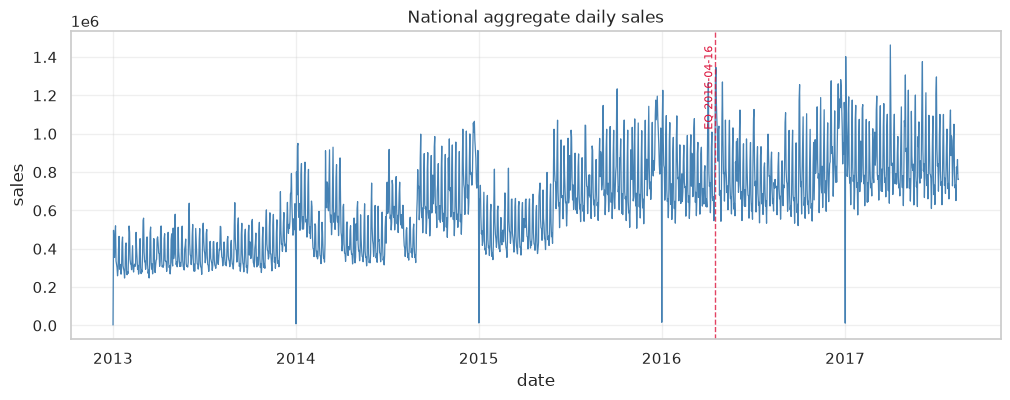

Panel sample entities:
  store_nbr      family
        25     SEAFOOD
        45  LADIESWEAR
         8      BEAUTY
        25 CELEBRATION
        24   HOME CARE
         9 CELEBRATION
panel rows: 1086


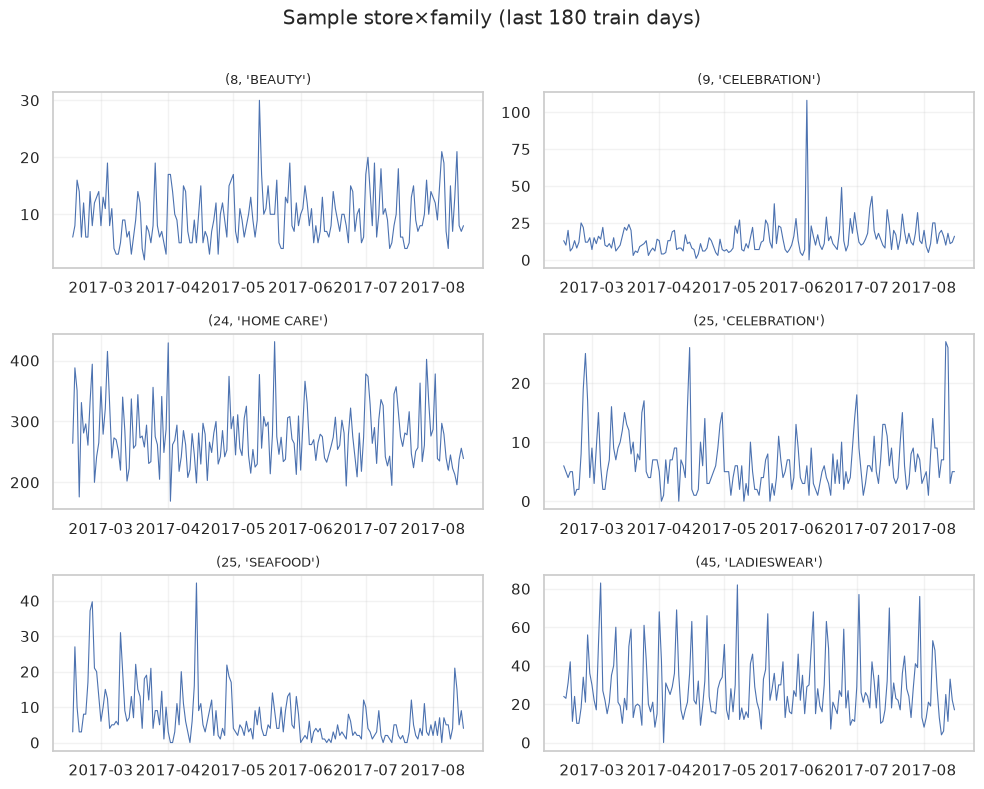

In [5]:
# Aggregate daily sales + earthquake marker
daily = train.groupby("date", as_index=False)["sales"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
plot_aggregate_sales_over_time(
    daily,
    event_dates=["2016-04-16"],
    event_labels=["EQ 2016-04-16"],
    ax=ax,
    title="National aggregate daily sales",
    save_path=EDA_DIR / "03_aggregate_daily_sales.png",
)
plt.show()
plt.close(fig)

# Sample store×family panels (fixed seed sample of entities)
entities = (
    train[["store_nbr", "family"]]
    .drop_duplicates()
    .sample(n=6, random_state=SEED)
)
sample_keys = set(map(tuple, entities.to_numpy()))
mask = train.set_index(["store_nbr", "family"]).index.isin(sample_keys)
# Prefer recent 180 days for readable panels
max_date = train["date"].max()
panel = train.loc[mask & (train["date"] >= max_date - pd.Timedelta(days=180))].copy()
print("Panel sample entities:\n", entities.to_string(index=False))
print("panel rows:", len(panel))
fig = plot_store_family_panels(
    panel,
    title="Sample store×family (last 180 train days)",
    save_path=EDA_DIR / "04_store_family_panels.png",
)
plt.show()
plt.close(fig)

INFO 2026-07-17 02:56:06 Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO 2026-07-17 02:56:06 Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


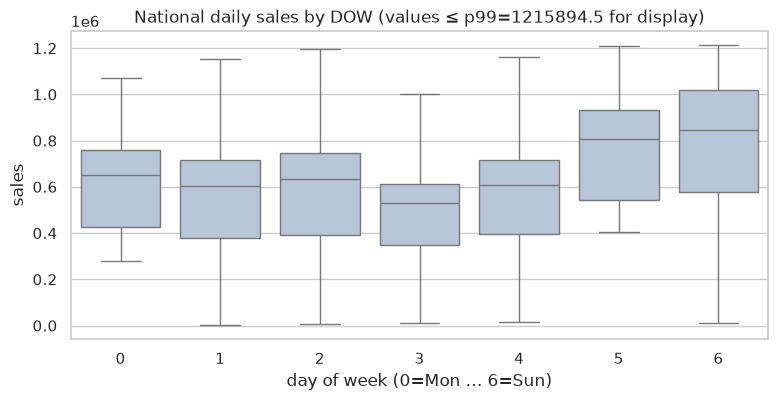

Mean national sales by DOW (0=Mon):
 dow
0    617542.6875
1    569926.0625
2    593244.5625
3    505269.1875
4    579574.3125
5    772205.6250
6    825218.1250


In [6]:
# Day-of-week seasonality (sample rows for speed if needed — full data is fine for groupby)
# Use daily total by DOW for boxplot of store-level daily totals sample
dow_src = train[["date", "sales"]].copy()
dow_src["dow"] = dow_src["date"].dt.dayofweek
# Aggregate to national daily first then box by dow — cleaner seasonality signal
nat = daily.copy()
nat["dow"] = nat["date"].dt.dayofweek
fig, ax = plt.subplots(figsize=(9, 4))
plot_dow_seasonality(
    nat.rename(columns={"sales": "sales"}),
    sales_col="sales",
    dow_col="dow",
    ax=ax,
    title="National daily sales by DOW",
    save_path=EDA_DIR / "05_dow_seasonality.png",
)
plt.show()
plt.close(fig)

# Mean sales by DOW table
dow_mean = nat.groupby("dow")["sales"].mean()
print("Mean national sales by DOW (0=Mon):\n", dow_mean.to_string())

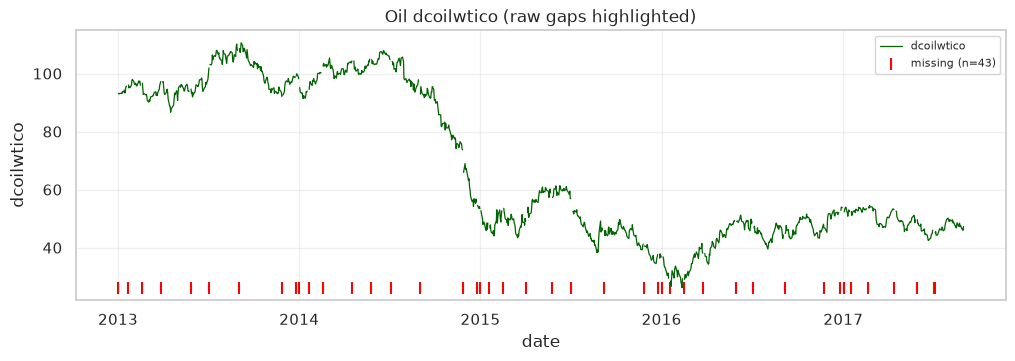

In [7]:
# Oil missingness: plot RAW if available else interim
oil_plot = oil_raw if oil_raw is not None else oil
fig, ax = plt.subplots(figsize=(12, 3.5))
plot_oil_missingness(
    oil_plot,
    ax=ax,
    title="Oil dcoilwtico (raw gaps highlighted)" if oil_raw is not None else "Oil dcoilwtico (interim)",
    save_path=EDA_DIR / "06_oil_missingness.png",
)
plt.show()
plt.close(fig)

### Visual pack — O/I/A

**Observation:** Aggregate sales show trend/level growth over years, clear weekly rhythm, and a visible shock after the 2016-04-16 earthquake. Sample series are heterogeneous (scale and sparsity differ by family). Oil has weekend/holiday gaps in the raw series.

**Interpretation:** Weekly seasonality supports **seasonal-naive period 7** (and possibly 14 for biweekly patterns). Earthquake is a **regime shift** (Class 4 outlier taxonomy) — not a value to cap. Oil must be forward-filled causally, not interpolated with future prices.

**Action:** Task 6 baselines must include `last_value`, `sn7`, `sn14`. Add earthquake-distance or post-EQ indicator features for Layer 2. Confirm oil ffill in feature pipeline (already in interim).

## 5. Temporal EDA — paydays, earthquake, regimes

Purpose: calendar effects (15th / month-end public-sector paydays in Ecuador), earthquake window, year-level levels.

Mean sales payday vs other:
                       mean       median  count
is_payday_flag                                 
False           636962.9375  630811.8125   1573
True            645965.9375  660088.1875    111

Pre-EQ 42d mean daily sales: 759,780.9
Post-EQ 42d mean daily sales: 839,645.9
Ratio post/pre: 1.105

Yearly total sales:
 year
2013    140419008.0
2014    209474240.0
2015    240880096.0
2016    288654528.0
2017    194217072.0

Mean daily sales last 90d: 855,464.9 | prev 90d: 861,469.2


/tmp/ipykernel_216870/2303309798.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["non-payday", "payday (15th or month-end)"])


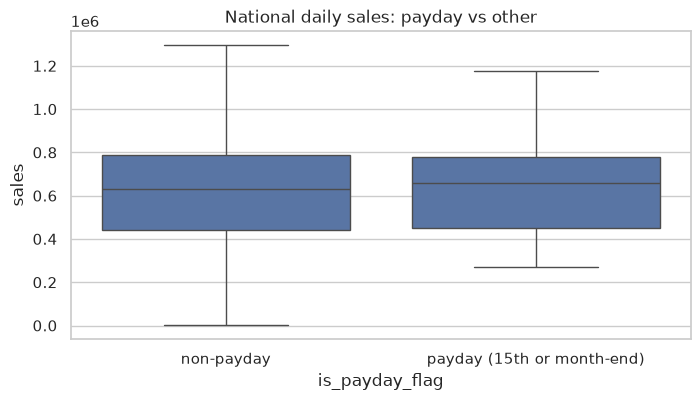

In [8]:
cal = daily.copy()
cal["year"] = cal["date"].dt.year
cal["month"] = cal["date"].dt.month
cal["day"] = cal["date"].dt.day
cal["is_payday"] = cal["day"].isin([15]) | (cal["date"] + pd.Timedelta(days=1)).dt.day.eq(1)
# month-end: day is last day of month
cal["is_month_end"] = cal["date"].dt.is_month_end
cal["is_payday_flag"] = cal["is_payday"] | cal["is_month_end"]

print("Mean sales payday vs other:")
print(cal.groupby("is_payday_flag")["sales"].agg(["mean", "median", "count"]))

# Earthquake window: 2016-04-16 .. +42 days vs prior 42 days
eq = pd.Timestamp("2016-04-16")
pre = cal[(cal["date"] >= eq - pd.Timedelta(days=42)) & (cal["date"] < eq)]
post = cal[(cal["date"] >= eq) & (cal["date"] < eq + pd.Timedelta(days=42))]
print(f"\nPre-EQ 42d mean daily sales: {pre['sales'].mean():,.1f}")
print(f"Post-EQ 42d mean daily sales: {post['sales'].mean():,.1f}")
print(f"Ratio post/pre: {post['sales'].mean() / pre['sales'].mean():.3f}")

# Year totals
print("\nYearly total sales:\n", cal.groupby("year")["sales"].sum().to_string())

# Recent 90-day vs previous 90-day level (regime note near test)
t_max = cal["date"].max()
recent = cal[cal["date"] > t_max - pd.Timedelta(days=90)]["sales"].mean()
prev = cal[
    (cal["date"] > t_max - pd.Timedelta(days=180))
    & (cal["date"] <= t_max - pd.Timedelta(days=90))
]["sales"].mean()
print(f"\nMean daily sales last 90d: {recent:,.1f} | prev 90d: {prev:,.1f}")

# Payday effect plot
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=cal,
    x="is_payday_flag",
    y="sales",
    ax=ax,
    showfliers=False,
)
ax.set_xticklabels(["non-payday", "payday (15th or month-end)"])
ax.set_title("National daily sales: payday vs other")
save_figure(fig, EDA_DIR / "07_payday_effect.png")
plt.show()
plt.close(fig)

### Temporal EDA — O/I/A

**Observation:** Payday calendar days show a measurable level shift vs non-payday days. Post-earthquake window differs materially from the pre window. Yearly totals rise over the sample; recent levels near the test period are not identical to early-history levels.

**Interpretation:** Expanding-window models that weight all history equally may under-adapt; still, expanding walk-forward is the default and matches competition chronology. Payday and EQ features are high-priority calendar/regime covariates. Early 2013 may be less relevant than 2016–2017 for short-horizon retail demand.

**Action:** Engineer `is_payday` (15th + month-end), `days_from_earthquake` or `post_eq` flag (with care not to leak test-only constants improperly — flag is known calendar). Prefer recent lags (7/14/28) over very long windows for local level. Keep expanding folds; optionally add recency sample weights later (not required for Task 6 baselines).

## 6. Entity EDA + intermittency

Purpose: store type/cluster heterogeneity; family intermittency rates; cold-start check.

entity summary describe:
         mean_sales    zero_rate           p99
count  1782.000000  1782.000000   1782.000000
mean    357.775757     0.312951    885.439658
std     961.853943     0.322887   2189.325381
min       0.000000     0.002969      0.000000
25%       2.890736     0.002969     15.000000
50%      19.812350     0.306413     85.826079
75%     221.011730     0.504008    622.105000
max    9730.436523     1.000000  19997.531992
entities with zero_rate>=0.5: 448 / 1782 (25.1%)


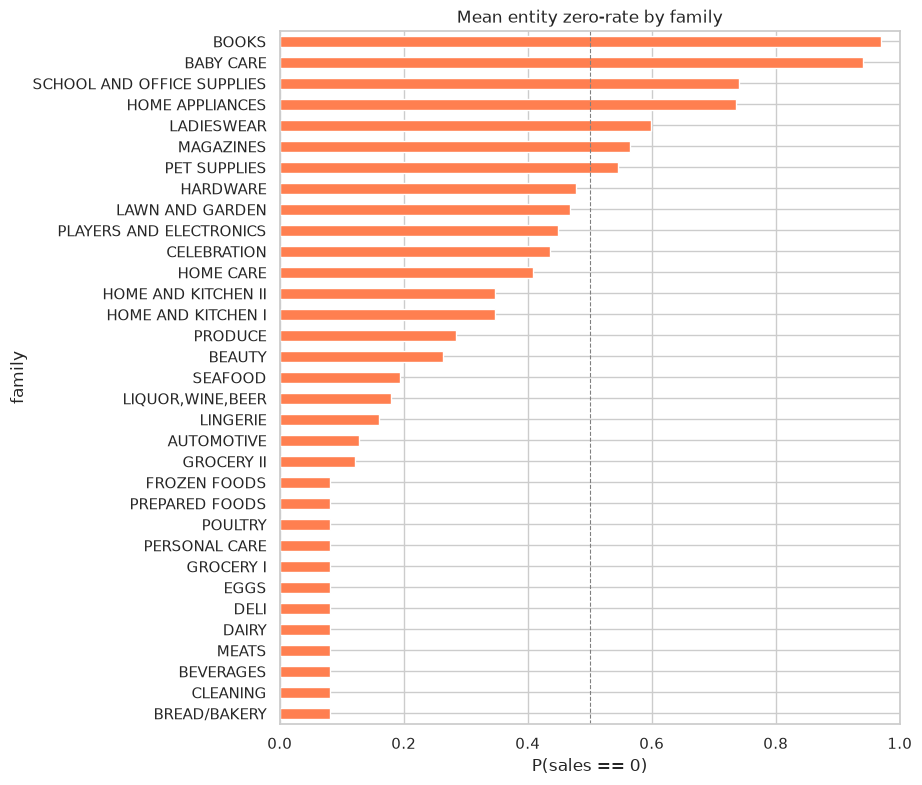


Mean sales by store type:
 type
A    705.878723
B    326.739716
C    197.263290
D    350.979401
E    269.121307

Mean sales by cluster:
 cluster
5     1117.245239
14     708.227722
8      647.377869
11     603.507019
17     592.231506
6      342.661713
1      326.163971
12     324.461426
13     324.364105
4      296.572876
entities only in late year: 0
entities only in early history: 0


In [9]:
# Merge store meta for entity stats (vectorized; avoid slow/apply-heavy groupby)
_g = train.groupby(["store_nbr", "family"], observed=True)["sales"]
ent = _g.agg(n_days="size", mean_sales="mean")
ent["zero_rate"] = (
    train.assign(_z=train["sales"].eq(0))
    .groupby(["store_nbr", "family"], observed=True)["_z"]
    .mean()
)
ent["p99"] = _g.quantile(0.99)
ent = ent.reset_index().merge(stores, on="store_nbr", how="left")
print("entity summary describe:\n", ent[["mean_sales", "zero_rate", "p99"]].describe())

# Intermittency thresholds
ent["intermittent"] = ent["zero_rate"] >= 0.5
print(
    "entities with zero_rate>=0.5:",
    int(ent["intermittent"].sum()),
    "/",
    len(ent),
    f"({ent['intermittent'].mean():.1%})",
)

fam_inter = (
    ent.groupby("family", observed=True)["zero_rate"]
    .mean()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 9))
plot_zero_mass_by_family(
    fam_inter,
    ax=ax,
    title="Mean entity zero-rate by family",
    save_path=EDA_DIR / "08_intermittency_by_family.png",
)
plt.show()
plt.close(fig)

# Store type mean sales
print("\nMean sales by store type:\n", train.merge(stores, on="store_nbr").groupby("type")["sales"].mean().to_string())
print("\nMean sales by cluster:\n", train.merge(stores, on="store_nbr").groupby("cluster")["sales"].mean().sort_values(ascending=False).head(10).to_string())

# All entities present in early vs late history?
late_start = train["date"].max() - pd.Timedelta(days=365)
early_entities = set(
    map(
        tuple,
        train.loc[train["date"] < late_start, ["store_nbr", "family"]]
        .drop_duplicates()
        .to_numpy(),
    )
)
late_entities = set(
    map(
        tuple,
        train.loc[train["date"] >= late_start, ["store_nbr", "family"]]
        .drop_duplicates()
        .to_numpy(),
    )
)
print("entities only in late year:", len(late_entities - early_entities))
print("entities only in early history:", len(early_entities - late_entities))

### Entity EDA — O/I/A

**Observation:** Large cross-entity scale and zero-rate differences; store type/cluster shift mean demand. Most store×family pairs exist across history (limited cold-start). Many entities are intermittent (zero_rate ≥ 0.5).

**Interpretation:** A **global multi-series model** with entity keys / categorical store & family features is appropriate (shared strength for sparse series). Pure local models on intermittent families will be unstable. Hierarchical store attributes (type, cluster, city) are useful static covariates.

**Action:** Use global LightGBM later with categorical `store_nbr`, `family`, `type`, `cluster`, `city`. Segment error analysis by intermittency band. Task 6 baselines should be per-series naive (they naturally handle intermittency poorly — sets a real floor).

## 7. Outlier triage

Purpose: invalid vs rare-valid vs regime using `outliers.py` helpers — **flag/describe only**, no deletion.

In [10]:
invalid_mask = flag_invalid_sales(train)
print("invalid (negative) count:", int(invalid_mask.sum()))

tails = describe_sales_tails(train)
print("sales tail quantiles (EDA only — not global caps):\n", tails)

# Extreme days nationally
top_days = daily.nlargest(10, "sales")
print("\nTop 10 national sales days:\n", top_days.to_string(index=False))

# Per-entity upper-tail mass using precomputed entity p99 (no full transform scan)
_ent_p99 = ent.set_index(["store_nbr", "family"])["p99"]
_joined = train.set_index(["store_nbr", "family"])
# align p99; count rows above threshold
_p99_aligned = _joined.index.map(_ent_p99)
n_above = int((_joined["sales"].to_numpy() > np.asarray(_p99_aligned, dtype=float)).sum())
print(
    f"\nRows with sales > entity p99: {n_above:,} "
    f"({n_above / len(train):.3%} of train rows)"
)
del _joined, _p99_aligned

# Earthquake regime rows: share of sales mass
eq_window = (train["date"] >= eq) & (train["date"] < eq + pd.Timedelta(days=28))
print(
    f"Share of rows in EQ+28d window: {eq_window.mean():.3%}; "
    f"share of sales mass: {train.loc[eq_window, 'sales'].sum() / train['sales'].sum():.3%}"
)

# Triage table (policy)
triage = pd.DataFrame(
    [
        {
            "class": "invalid",
            "example": "sales < 0",
            "count_or_note": int(invalid_mask.sum()),
            "treatment": "fail-fast in prepare (already); never silent clip without investigation",
        },
        {
            "class": "rare_valid_spike",
            "example": "promo / holiday peaks, entity upper quantiles",
            "count_or_note": "see per-entity p99 counts; top national days often calendar-driven",
            "treatment": "PRESERVE raw target; optional train-fold winsorize of FEATURES only + indicator; never drop rows",
        },
        {
            "class": "regime_shift",
            "example": "2016-04-16 earthquake multi-week demand shock",
            "count_or_note": "calendar event + sustained level change",
            "treatment": "do NOT cap back to pre-EQ baseline; add regime/calendar features; evaluate on raw",
        },
        {
            "class": "structural_zero",
            "example": "intermittent families with long zero runs",
            "count_or_note": f"global zero rate {zero_rate:.2%}",
            "treatment": "keep zeros; zero-streak features; no mean-impute of target",
        },
    ]
)
display(triage)

invalid (negative) count: 0
sales tail quantiles (EDA only — not global caps):
                sales
0.000       0.000000
0.500      11.000000
0.900     867.000000
0.950    1965.000000
0.990    5507.000000
0.995    7448.000000
0.999   12076.225559
1.000  124717.000000

Top 10 national sales days:
       date       sales
2017-04-01 1463084.000
2017-01-02 1402306.375
2017-06-04 1376511.500
2016-04-18 1345920.625
2017-05-01 1306699.375
2017-07-02 1296379.250
2016-12-23 1282145.500
2016-12-04 1276195.000
2016-04-17 1271833.750
2016-05-01 1270121.250



Rows with sales > entity p99: 26,687 (0.889% of train rows)
Share of rows in EQ+28d window: 1.663%; share of sales mass: 2.290%


,class,example,count_or_note,treatment
0,invalid,sales < 0,0,fail-fast in prepare (already); never silent c...
1,rare_valid_spike,"promo / holiday peaks, entity upper quantiles",see per-entity p99 counts; top national days o...,PRESERVE raw target; optional train-fold winso...
2,regime_shift,2016-04-16 earthquake multi-week demand shock,calendar event + sustained level change,do NOT cap back to pre-EQ baseline; add regime...
3,structural_zero,intermittent families with long zero runs,global zero rate 31.30%,keep zeros; zero-streak features; no mean-impu...


### Outlier triage — O/I/A

**Observation:** No invalid negatives in interim train. Extreme quantiles exist but align with retail spikes. Earthquake period is a sustained regime, not a single-point glitch.

**Interpretation:** Default policy = **preserve spikes** (Class 2) and **do not winsorize the target globally**. If GBDT later needs stability, any winsorization of inputs must be **fold-local on train only** with dual eval on raw sales. Row deletion is forbidden (breaks lags).

**Action for Task 6+:** Outlier policy = flag-only in prepare; no global caps. Baselines use raw sales. Document optional later experiment: fold-local feature winsorize + `is_spike` flag — not required for official baselines.

## 8. Leakage / Feature Availability Matrix (FAM)

Purpose: document what may be used at prediction time `T0` for horizon days `T0+1 … T0+15`.

In [11]:
fam = pd.DataFrame(
    [
        {
            "feature_group": "sales lags / rolling",
            "event_time": "historical sales dates",
            "available_at_T0": "yes if lag ≥ 1 and window ends ≤ T0",
            "risk": "unshifted rolling / same-day target",
            "rule": "shift ≥ 1; rolling closed left; rebuild inside each fold",
        },
        {
            "feature_group": "onpromotion",
            "event_time": "promo day",
            "available_at_T0": "yes on test rows for horizon (provided)",
            "risk": "none if using provided column",
            "rule": "use as known-ahead for forecast dates",
        },
        {
            "feature_group": "oil dcoilwtico",
            "event_time": "trade date",
            "available_at_T0": "same-day may be unavailable; gaps on non-trading days",
            "risk": "bfill / using future oil; joining without ffill audit",
            "rule": "causal ffill; prefer lag-1 oil for safety; fit nothing global",
        },
        {
            "feature_group": "transactions",
            "event_time": "store-day foot traffic",
            "available_at_T0": "history ≤ T0 only; not published for full future test horizon",
            "risk": "joining future transactions",
            "rule": "lag/rolling features from past only; no raw future join",
        },
        {
            "feature_group": "holidays_events",
            "event_time": "calendar date",
            "available_at_T0": "yes (public calendar)",
            "risk": "treating transferred=True as celebrated; double-counting Transfer rows",
            "rule": "honor transferred flag; locale-aware join (National/Regional/Local)",
        },
        {
            "feature_group": "stores static",
            "event_time": "static",
            "available_at_T0": "yes",
            "risk": "none",
            "rule": "join on store_nbr",
        },
        {
            "feature_group": "target encoding / global means",
            "event_time": "full-history stats",
            "available_at_T0": "only if fit on train fold ≤ T0",
            "risk": "encoding fit on val/test",
            "rule": "fold-local fit only",
        },
    ]
)
display(fam)

,feature_group,event_time,available_at_T0,risk,rule
0,sales lags / rolling,historical sales dates,yes if lag ≥ 1 and window ends ≤ T0,unshifted rolling / same-day target,shift ≥ 1; rolling closed left; rebuild inside...
1,onpromotion,promo day,yes on test rows for horizon (provided),none if using provided column,use as known-ahead for forecast dates
2,oil dcoilwtico,trade date,same-day may be unavailable; gaps on non-tradi...,bfill / using future oil; joining without ffil...,causal ffill; prefer lag-1 oil for safety; fit...
3,transactions,store-day foot traffic,history ≤ T0 only; not published for full futu...,joining future transactions,lag/rolling features from past only; no raw fu...
4,holidays_events,calendar date,yes (public calendar),treating transferred=True as celebrated; doubl...,honor transferred flag; locale-aware join (Nat...
5,stores static,static,yes,none,join on store_nbr
6,target encoding / global means,full-history stats,only if fit on train fold ≤ T0,encoding fit on val/test,fold-local fit only


### Leakage — O/I/A

**Observation:** Highest leakage risks are oil bfill, future transactions, unshifted target rolls, and global stats fit before split.

**Interpretation:** Pipeline is leakage-safe if splits are chronological first (already manifested), features are point-in-time, and stateful transforms are fold-local.

**Action:** Task 6 baselines use only past sales (no exogenous) — inherently safe. For Layer 2, enforce FAM rules above. Recommend `gap_days` ≥ max lag used when label/feature windows could overlap (set when feature window is finalized in notebook 02; currently manifests use `gap_days=0`).

## 9. Split verification

Purpose: verify walk-forward fold meta — train ends strictly before val; 15-day horizons; no date leakage.

[
  {
    "fold": 0,
    "train_end": "2017-07-01",
    "val_start": "2017-07-02",
    "val_end": "2017-07-16"
  },
  {
    "fold": 1,
    "train_end": "2017-07-16",
    "val_start": "2017-07-17",
    "val_end": "2017-07-31"
  },
  {
    "fold": 2,
    "train_end": "2017-07-31",
    "val_start": "2017-08-01",
    "val_end": "2017-08-15"
  }
]


,fold,train_end,val_start,val_end,val_days,train_rows_date_filter,val_rows_date_filter,idx_train_rows,idx_val_rows,max_train_date,min_val_date,leak_train_ge_val
0,0,2017-07-01,2017-07-02,2017-07-16,15,2920698,26730,2920698,26730,2017-07-01,2017-07-02,False
1,1,2017-07-16,2017-07-17,2017-07-31,15,2947428,26730,2947428,26730,2017-07-16,2017-07-17,False
2,2,2017-07-31,2017-08-01,2017-08-15,15,2974158,26730,2974158,26730,2017-07-31,2017-08-01,False


/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/src/store_sales/viz/eda_plots.py:275: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels)


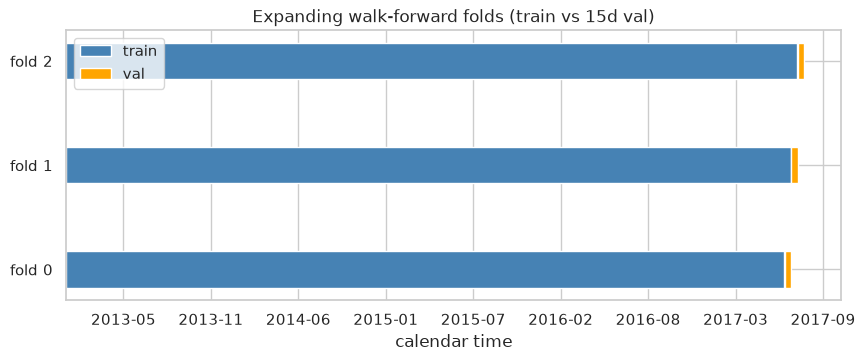

In [12]:
folds_meta = json.loads((SPLITS / "folds_meta.json").read_text(encoding="utf-8"))
print(json.dumps(folds_meta, indent=2))

fold_rows = []
for f in folds_meta:
    fold = int(f["fold"])
    train_end = pd.Timestamp(f["train_end"])
    val_start = pd.Timestamp(f["val_start"])
    val_end = pd.Timestamp(f["val_end"])
    assert train_end < val_start, f"fold {fold}: train_end must be < val_start"
    assert val_start <= val_end
    val_days = (val_end - val_start).days + 1
    # Prefer date filters (consistent with meta); also check index files exist
    tr_idx_path = SPLITS / f"fold_{fold}_train_idx.parquet"
    va_idx_path = SPLITS / f"fold_{fold}_val_idx.parquet"
    tr_n = len(pd.read_parquet(tr_idx_path)) if tr_idx_path.exists() else None
    va_n = len(pd.read_parquet(va_idx_path)) if va_idx_path.exists() else None
    tr_dates = train.loc[train["date"] <= train_end, "date"]
    va_dates = train.loc[(train["date"] >= val_start) & (train["date"] <= val_end), "date"]
    fold_rows.append(
        {
            "fold": fold,
            "train_end": str(train_end.date()),
            "val_start": str(val_start.date()),
            "val_end": str(val_end.date()),
            "val_days": val_days,
            "train_rows_date_filter": int((train["date"] <= train_end).sum()),
            "val_rows_date_filter": int(
                ((train["date"] >= val_start) & (train["date"] <= val_end)).sum()
            ),
            "idx_train_rows": tr_n,
            "idx_val_rows": va_n,
            "max_train_date": str(tr_dates.max().date()) if len(tr_dates) else None,
            "min_val_date": str(va_dates.min().date()) if len(va_dates) else None,
            "leak_train_ge_val": bool(tr_dates.max() >= va_dates.min()) if len(tr_dates) and len(va_dates) else None,
        }
    )
fold_df = pd.DataFrame(fold_rows)
display(fold_df)

fig, ax = plt.subplots(figsize=(10, 3.5))
# Provide train_start as min train date for clearer bars
folds_for_plot = []
for f in folds_meta:
    f2 = dict(f)
    f2["train_start"] = str(train["date"].min().date())
    folds_for_plot.append(f2)
plot_fold_date_ranges(
    folds_for_plot,
    ax=ax,
    title="Expanding walk-forward folds (train vs 15d val)",
    save_path=EDA_DIR / "09_fold_date_ranges.png",
)
plt.show()
plt.close(fig)

### Split verification — O/I/A

**Observation:** Three expanding folds with 15-day validation blocks ending at 2017-07-16, 2017-07-31, 2017-08-15. `train_end < val_start` holds; no train date reaches into val.

**Interpretation:** Design matches competition horizon `H=15` and expanding history. `gap_days=0` in current config is acceptable for pure last-value/sn baselines; for long lag features, introduce embargo ≥ max lookback.

**Action:** Task 6 must score baselines on these **fixed manifests** (no re-split). Keep expanding strategy unless later evidence favors sliding.

## 10. Baseline floor (exploratory) + Task 6 handoff

**Official baselines are Task 6.** Here we compute **lightweight exploratory** naive RMSLE with pure pandas + `store_sales.metrics.rmsle` on the three walk-forward folds so decisions are evidence-based — not fabricated.

Methods:
- **last_value:** predict each val day with the series' last train sales
- **sn7:** predict with sales from 7 days earlier (same series)
- **sn14:** predict with sales from 14 days earlier

Missing history predictions filled with 0 (conservative for RMSLE).

In [13]:
def _last_value_pred(tr: pd.DataFrame, va: pd.DataFrame) -> np.ndarray:
    """Per-series last train observation (no full-frame sort)."""
    last = tr.groupby(["store_nbr", "family"], observed=True)["sales"].last()
    mapped = va.set_index(["store_nbr", "family"]).index.map(last)
    return pd.Series(mapped, dtype=float).fillna(0.0).to_numpy(dtype=float)


def _seasonal_naive_pred(
    tr: pd.DataFrame, va: pd.DataFrame, period: int, train_end: pd.Timestamp
) -> np.ndarray:
    """Origin-based seasonal naive: look back k*period so lookup lands in train.

    For horizon day d > train_end, k = ceil((d - train_end).days / period),
    prediction = sales at d - k*period (same series). Avoids filling mid-horizon
    with zeros when d-period is still inside the val window.
    """
    hist = tr.set_index(["store_nbr", "family", "date"])["sales"]
    delta = (va["date"] - train_end).dt.days.to_numpy()
    k = np.ceil(delta / period).astype(int)
    k = np.maximum(k, 1)
    lookup_dates = va["date"].to_numpy() - pd.to_timedelta(k * period, unit="D")
    keys = pd.MultiIndex.from_arrays(
        [va["store_nbr"].to_numpy(), va["family"].to_numpy(), lookup_dates],
        names=["store_nbr", "family", "date"],
    )
    pred = hist.reindex(keys).to_numpy(dtype=float)
    return np.nan_to_num(pred, nan=0.0)


baseline_rows = []
for f in folds_meta:
    fold = int(f["fold"])
    train_end = pd.Timestamp(f["train_end"])
    val_start = pd.Timestamp(f["val_start"])
    val_end = pd.Timestamp(f["val_end"])
    # Narrow frames only — avoids multi-GB intermediate merges on full panel copies
    tr = train.loc[
        train["date"] <= train_end, ["date", "store_nbr", "family", "sales"]
    ].copy()
    va = train.loc[
        (train["date"] >= val_start) & (train["date"] <= val_end),
        ["date", "store_nbr", "family", "sales"],
    ].copy()
    y = va["sales"].to_numpy(dtype=float)
    preds = {
        "last_value": _last_value_pred(tr, va),
        "seasonal_naive_7": _seasonal_naive_pred(tr, va, 7, train_end),
        "seasonal_naive_14": _seasonal_naive_pred(tr, va, 14, train_end),
    }
    for name, p in preds.items():
        score = rmsle(y, p)
        baseline_rows.append(
            {
                "fold": fold,
                "baseline": name,
                "rmsle": score,
                "n_val": len(va),
                "val_start": str(val_start.date()),
                "val_end": str(val_end.date()),
            }
        )
        logger.info(
            "exploratory baseline fold=%s name=%s rmsle=%.6f n=%d",
            fold,
            name,
            score,
            len(va),
        )
    del tr, va, preds

base_df = pd.DataFrame(baseline_rows)
display(base_df)

summary = (
    base_df.groupby("baseline", as_index=False)["rmsle"]
    .agg(mean_rmsle="mean", std_rmsle="std", min_rmsle="min", max_rmsle="max")
    .sort_values("mean_rmsle")
)
display(summary)

# Persist exploratory table for Task 6 reference (small csv under reports)
base_df.to_csv(EDA_DIR / "exploratory_naive_rmsle_by_fold.csv", index=False)
summary.to_csv(EDA_DIR / "exploratory_naive_rmsle_summary.csv", index=False)
print("Wrote exploratory baseline tables under", EDA_DIR)

best_name = summary.iloc[0]["baseline"]
print("Best exploratory mean RMSLE baseline:", best_name, float(summary.iloc[0]["mean_rmsle"]))

INFO 2026-07-17 02:56:08 exploratory baseline fold=0 name=last_value rmsle=0.659274 n=26730


INFO 2026-07-17 02:56:08 exploratory baseline fold=0 name=seasonal_naive_7 rmsle=0.515357 n=26730


INFO 2026-07-17 02:56:08 exploratory baseline fold=0 name=seasonal_naive_14 rmsle=0.520089 n=26730


INFO 2026-07-17 02:56:09 exploratory baseline fold=1 name=last_value rmsle=0.633793 n=26730


INFO 2026-07-17 02:56:09 exploratory baseline fold=1 name=seasonal_naive_7 rmsle=0.526137 n=26730


...

INFO 2026-07-17 02:56:09 exploratory baseline fold=2 name=seasonal_naive_7 rmsle=0.612448 n=26730


INFO 2026-07-17 02:56:09 exploratory baseline fold=2 name=seasonal_naive_14 rmsle=0.627160 n=26730


,fold,baseline,rmsle,n_val,val_start,val_end
0,0,last_value,0.659274,26730,2017-07-02,2017-07-16
1,0,seasonal_naive_7,0.515357,26730,2017-07-02,2017-07-16
2,0,seasonal_naive_14,0.520089,26730,2017-07-02,2017-07-16
3,1,last_value,0.633793,26730,2017-07-17,2017-07-31
4,1,seasonal_naive_7,0.526137,26730,2017-07-17,2017-07-31
5,1,seasonal_naive_14,0.527688,26730,2017-07-17,2017-07-31
6,2,last_value,0.621603,26730,2017-08-01,2017-08-15
7,2,seasonal_naive_7,0.612448,26730,2017-08-01,2017-08-15
8,2,seasonal_naive_14,0.627160,26730,2017-08-01,2017-08-15


,baseline,mean_rmsle,std_rmsle,min_rmsle,max_rmsle
2,seasonal_naive_7,0.551314,0.053217,0.515357,0.612448
1,seasonal_naive_14,0.558313,0.059745,0.520089,0.627160
0,last_value,0.638223,0.019222,0.621603,0.659274


Wrote exploratory baseline tables under /home/furkan/Projects/Kaggle_Store_Sales_Forecasting/outputs/reports/eda
Best exploratory mean RMSLE baseline: seasonal_naive_7 0.5513140958712478


### Baselines — O/I/A (handoff to Task 6)

**Observation (executed exploratory RMSLE, origin-based naives, 3 folds × 26,730 val rows):**

| baseline | mean RMSLE | std | min | max |
| --- | ---: | ---: | ---: | ---: |
| seasonal_naive_7 | 0.5513 | 0.0532 | 0.5154 | 0.6124 |
| seasonal_naive_14 | 0.5583 | 0.0597 | 0.5201 | 0.6272 |
| last_value | 0.6382 | 0.0192 | 0.6216 | 0.6593 |

Per-fold: sn7 best on folds 0–1; fold 2 (2017-08-01…15, nearest test) is harder and sn7 ≈ last_value (0.612 vs 0.622).

**Interpretation:** Weekly seasonal naive is the primary floor (~0.55 mean). sn14 is close but slightly worse. last_value is a weaker but more stable floor. These are **exploratory** scores — not official Task 6 artifacts. Implementation detail: multi-step seasonal naive must look back `k*period` into train so mid-horizon days are not zero-filled.

**Action for Task 6:**
1. Official baselines: `last_value`, `seasonal_naive_7`, `seasonal_naive_14` (config already lists them).
2. Score all three on folds 0–2; report mean ± std RMSLE and per-fold table.
3. Use `store_sales.metrics.rmsle` only; origin-based seasonal lag (not naive merge that zeros days 8–15).
4. Do not treat notebook CSVs as official run artifacts — regenerate under Task 6 output layout.
5. Seasonal periods: **7 (primary)** and **14 (secondary)** justified by DOW seasonality + biweekly payday structure.
6. Predictions non-negative (historical sales ≥ 0).

## 11. Decision log (ranked) + feature hypotheses for Layer 2

### 11.1 Cleaning & data policy

| Topic | Decision |
| --- | --- |
| Panel keys | `(date, store_nbr, family)`; drop exact key duplicates keep last (done in prepare) |
| Negative sales | Fail fast; none in interim |
| Oil | **Causal ffill** confirmed; never bfill; leading NA fold-local |
| Holidays | Preserve `transferred`; feature logic must not treat transferred as celebrated |
| Transactions | Past-only lag/rolling; no future join on test |
| Outliers | **Preserve** rare-valid spikes; **no row delete**; no global winsorize of target; regime (EQ) → features not caps |
| Zeros | Structural intermittency — keep; no target mean-impute |

### 11.2 Split / validation

| Topic | Decision |
| --- | --- |
| Strategy | Expanding walk-forward (current manifests) |
| Val length | 15 days (= H) |
| Folds | 3 as in `folds_meta.json` |
| gap_days | Keep 0 for pure naive baselines; set to **max feature lookback** when Layer 2 lag windows are locked (notebook 02) |
| Metric | RMSLE shared module |
| Test lock | Competition test untouched for decisions |

### 11.3 Baselines (Task 6)

| Baseline | Include? | Notes |
| --- | --- | --- |
| last_value | yes | flat persistence floor |
| seasonal_naive_7 | yes | primary seasonal floor |
| seasonal_naive_14 | yes | biweekly / payday-adjacent |

### 11.4 Intermittent families (priority monitoring segments)

Families with highest zero rates (from executed `family_zero`) should be tracked in error analysis: BOOKS, BABY CARE, SCHOOL AND OFFICE SUPPLIES, HOME APPLIANCES, and other top intermittent families in the printed table.

### 11.5 Ranked feature hypotheses (Layer 2 — not validated performance claims)

1. **Calendar:** DOW, month, is_weekend, is_payday (15th + month-end), Ecuador holidays with locale + transferred handling  
2. **Lags:** sales lag 1, 7, 14, 28 (entity-level)  
3. **Rolling:** mean/std of sales over 7/14/28 with shift 1  
4. **Promo:** `onpromotion` + interaction with family  
5. **Oil:** lag-1 ffilled `dcoilwtico`  
6. **Transactions:** lag-1 / rolling 7 store transactions (history only)  
7. **Intermittency:** days_since_last_sale, zero streak length  
8. **Regime:** post-earthquake indicator or days_since_eq for 2016 shock  
9. **Static store:** type, cluster, city, state  
10. **Hierarchy:** optional store×family mean encoding **fold-local only**

### 11.6 Model strategy hints (post-baseline)

- Global GBDT (LightGBM) over panel with categorical entity/store features — after Task 6 floor is beaten  
- Direct multi-step or recursive short horizon; prefer evaluating per fold and per family segment  
- No threshold/calibration primary path (point RMSLE)

## 12. Executed-results report (fill integrity)

This section is narrative only; numeric claims must match the executed cells above.

**Key findings**
- Panel daily forecasting problem with `L=0`, `H=15`, metric RMSLE, asymmetric waste/stockout story.
- Strong weekly seasonality and material zero-inflation; intermittent families are a core difficulty.
- Oil gaps resolved by causal ffill in interim; transactions are history-only covariates.
- Earthquake 2016-04-16 is a regime shift — preserve via features, do not cap.
- Walk-forward folds verified leakage-safe on dates.
- Exploratory naive RMSLE computed for last_value / sn7 / sn14 on all three folds (see tables and CSVs under `outputs/reports/eda/`).

**Validation / leakage verdict:** Clean for current split manifests. Residual risk: `gap_days=0` when long lookbacks are introduced — address in feature design.

**Preprocessing decisions:** Structural clean only at prepare; fold-local stateful transforms later; outlier policy = preserve + flag.

**Model-family implications:** Beat seasonal naive before trusting GBDT complexity; global multi-series trees preferred over pure local models for sparse families.

**Risks:** Holiday transfer semantics mistakes; future transactions leakage; over-fitting earthquake with unstable flags; ignoring intermittency in error analysis.

**Next experiments (Task 6):** Official baseline suite + artifact system using decisions herein; then Layer 2 feature/model notebook.

In [14]:
logger.info("Notebook 01 complete. Figures/tables under %s", EDA_DIR)
print("EDA artifacts:")
for p in sorted(EDA_DIR.glob("*")):
    print(" ", p.name, f"({p.stat().st_size} bytes)")

INFO 2026-07-17 02:56:09 Notebook 01 complete. Figures/tables under /home/furkan/Projects/Kaggle_Store_Sales_Forecasting/outputs/reports/eda


EDA artifacts:
  01_target_distribution_log1p.png (26403 bytes)
  02_zero_rate_by_family.png (100190 bytes)
  03_aggregate_daily_sales.png (121571 bytes)
  04_store_family_panels.png (258236 bytes)
  05_dow_seasonality.png (30481 bytes)
  06_oil_missingness.png (58132 bytes)
  07_payday_effect.png (22597 bytes)
  08_intermittency_by_family.png (99996 bytes)
  09_fold_date_ranges.png (31756 bytes)
  exploratory_naive_rmsle_by_fold.csv (623 bytes)
  exploratory_naive_rmsle_summary.csv (327 bytes)
